In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import os
from pathlib import Path

In [2]:
folder = "images/panorama_set"

images = []

for file in sorted(os.listdir(folder)):
    path = os.path.join(folder, file)
    img = cv2.imread(path)
    
    if img is not None:
        images.append(img)
        print("Loaded:", file)


Loaded: panorama_1.jpg
Loaded: panorama_2.jpg
Loaded: panorama_3.jpg
Loaded: panorama_4.jpg


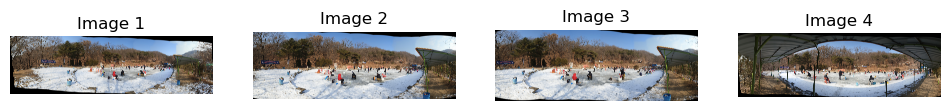

In [3]:
plt.figure(figsize=(12,6))

for i,img in enumerate(images):
    
    plt.subplot(1,len(images),i+1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [4]:
def detect_and_match(img1,img2):

    gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(2000)

    kp1,des1 = orb.detectAndCompute(gray1,None)
    kp2,des2 = orb.detectAndCompute(gray2,None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1,des2,k=2)

    good=[]

    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)

    return kp1,kp2,good

In [5]:
def find_homography(kp1,kp2,matches):

    if len(matches) < 10:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H,_ = cv2.findHomography(src_pts,dst_pts,cv2.RANSAC,5)

    return H

In [6]:
def stitch(img1,img2,H):

    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]

    corners = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
    warped = cv2.perspectiveTransform(corners,H)

    all_corners = np.concatenate((np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2),warped),axis=0)

    xmin,ymin = np.int32(all_corners.min(axis=0).ravel()-0.5)
    xmax,ymax = np.int32(all_corners.max(axis=0).ravel()+0.5)

    shift = [-xmin,-ymin]

    H_shift = np.array([
        [1,0,shift[0]],
        [0,1,shift[1]],
        [0,0,1]
    ])

    result = cv2.warpPerspective(img2,H_shift.dot(H),(xmax-xmin,ymax-ymin))

    result[shift[1]:h1+shift[1],shift[0]:w1+shift[0]] = img1

    return result

In [7]:
panorama = images[0]

for i in range(1,len(images)):

    print("Stitching image",i+1)

    kp1,kp2,matches = detect_and_match(panorama,images[i])

    H = find_homography(kp1,kp2,matches)

    if H is not None:
        panorama = stitch(panorama,images[i],H)
    else:
        print("Not enough matches")


Stitching image 2
Stitching image 3
Stitching image 4


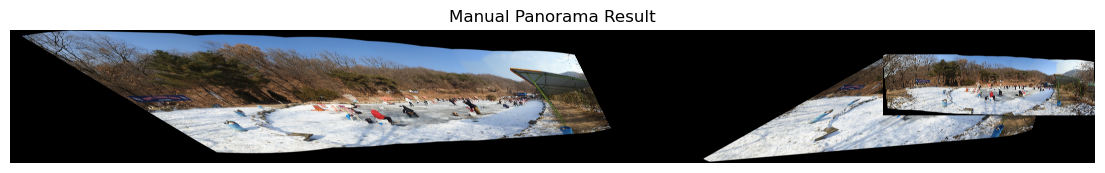

In [8]:
plt.figure(figsize=(14,7))
plt.imshow(cv2.cvtColor(panorama,cv2.COLOR_BGR2RGB))
plt.title("Manual Panorama Result")
plt.axis("off")
plt.show()

Running OpenCV Auto Stitcher...
Stitching Successful


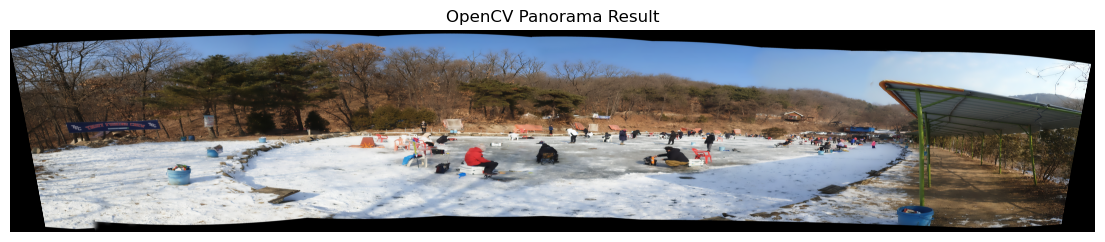

In [9]:
print("Running OpenCV Auto Stitcher...")

stitcher = cv2.Stitcher_create()

status,pano = stitcher.stitch(images)

if status == cv2.Stitcher_OK:

    print("Stitching Successful")

    plt.figure(figsize=(14,7))
    plt.imshow(cv2.cvtColor(pano,cv2.COLOR_BGR2RGB))
    plt.title("OpenCV Panorama Result")
    plt.axis("off")
    plt.show()

    cv2.imwrite("final_panorama.jpg",pano)

else:
    print("Stitching Failed:",status)